<a href="https://colab.research.google.com/github/sibemutech-blue/JORGE-ARTURO-SIMENTAL-BEAVEN-MURUA/blob/main/Copy_of_Sprint07_Webinar11_students_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint 7 · Sesión práctica · Proyecto guiado con Python — Versión estudiante

**Duración:** 120 minutos  
**Pausa:** 5 minutos a la mitad  
**Modalidad:** Proyecto práctico guiado en Google Colab  
**Nivel:** Introductorio-intermedio  

En esta sesión vamos a trabajar como analistas de datos de una tienda multicanal LATAM. El objetivo no es memorizar código, sino aprender un flujo de trabajo práctico: cargar datos, explorarlos, limpiarlos, automatizar tareas simples, graficar, detectar outliers, segmentar ventas y cerrar con conclusiones accionables.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cómo usar esta versión estudiante

Este notebook está preparado para que tomes apuntes, completes ejercicios y documentes tus decisiones durante la clase.

**Modo de trabajo recomendado:**

1. Lee primero la consigna de cada bloque o ejercicio.
2. Completa los espacios de respuesta antes de comparar con la explicación del instructor/a.
3. Ejecuta las celdas de setup cuando existan.
4. Escribe interpretación, dudas y decisiones en los espacios de apuntes.
5. Al final, revisa si tus respuestas conectan datos, método e implicación de negocio.

> Las salidas de ejecución fueron limpiadas para que puedas correr el notebook desde cero.


## Notas de clase principales

- El proyecto guiado integra carga, exploración, limpieza, automatización, KPIs, visualización y reporte.
- Trabaja de forma incremental: validar, limpiar, calcular, visualizar e interpretar.
- Los ciclos y funciones reducen repetición cuando se revisan varias columnas o reglas.
- Las visualizaciones deben ser consistentes con la pregunta analítica y el tipo de variable.
- El resultado final debe incluir dataset limpio, KPIs principales y conclusiones accionables.

### Mis notas iniciales

-
-
-


## Fecha

Completa la información de la sesión:

- **Fecha:**  30 de julio del 2026
- **Instructor/a:**  Julio Mtz
- **Duración:** 120 minutos  
- **Dataset:** `sprint07_proyecto_ventas_multicanal_latam.csv`

## Objetivos de aprendizaje

Al finalizar la sesión, la persona estudiante podrá:

1. Cargar un archivo `.csv` en Google Colab usando Pandas.
2. Explorar estructura, tipos de datos, valores nulos y métricas descriptivas.
3. Aplicar reglas simples de limpieza sin modificar el dataset original directamente.
4. Usar listas, ciclos `for`, ciclos `while` y funciones pequeñas para automatizar revisiones.
5. Calcular KPIs de negocio con `groupby()`.
6. Crear gráficas sencillas con `.plot()`.
7. Crear gráficas agrupadas con Seaborn usando `hue`.
8. Detectar posibles outliers con la regla IQR.
9. Crear segmentos de venta con funciones y `.apply()`.
10. Comunicar hallazgos con una estructura clara: contexto, hallazgo, evidencia e implicación.

## Agenda sugerida · 120 minutos

| Tiempo | Bloque | Actividad | Modalidad |
|---:|---|---|---|
| 0–10 min | Kickoff | Entender el caso de negocio y las preguntas guía | Discusión rápida |
| 10–20 min | Setup | Preparar Colab, cargar librerías y leer el CSV | Demo guiada |
| 20–35 min | Exploración inicial | `head()`, `shape`, `info()`, nulos y descriptivos | Coding together |
| 35–50 min | Limpieza | Copia segura, normalización de textos e imputaciones simples | Coding together |
| 50–60 min | Automatización | `for`, `while` y funciones pequeñas | Mini-reto guiado |
| 60–65 min | Pausa | Descanso corto | Break |
| 65–80 min | KPIs | Revenue, margen, ticket promedio, devoluciones | Coding together |
| 80–95 min | Visualización | Gráficas con `.plot()` y lectura de patrones | Demo + práctica |
| 95–108 min | Seaborn agrupado | Comparar categorías/canales/tipos de cliente con `hue` | Práctica guiada |
| 108–116 min | Outliers y segmentación | IQR y clasificación de ventas | Reto final |
| 116–120 min | Cierre | Validación, takeaways y canales de ayuda | Plenaria |

## Caso de negocio · Ventas Multicanal LATAM

La empresa vende productos por **Web**, **App**, **Tienda física** y **WhatsApp** en varios países de Latinoamérica. El equipo directivo quiere responder:

- ¿Qué países, canales y categorías generan más ingreso?
- ¿Dónde se concentra el margen?
- ¿Qué segmentos de ventas existen?
- ¿Hay ventas atípicas que puedan distorsionar el análisis?
- ¿Qué visualizaciones ayudan a explicar los hallazgos?

Durante la sesión se irá construyendo una versión limpia del dataset y un pequeño set de hallazgos para presentar al negocio.

## Diccionario de datos

| Columna | Descripción |
|---|---|
| `venta_id` | Identificador único de la venta |
| `fecha` | Fecha de la venta |
| `pais`, `region`, `ciudad` | Ubicación de la operación |
| `canal` | Canal de venta: Web, App, Tienda física o WhatsApp |
| `categoria` | Categoría del producto vendido |
| `metodo_pago` | Medio de pago usado por el cliente |
| `tipo_cliente` | Cliente nuevo o recurrente |
| `unidades` | Cantidad de unidades vendidas |
| `precio_unitario` | Precio unitario antes de descuentos |
| `descuento_pct` | Porcentaje de descuento aplicado |
| `ingreso` | Valor de la venta después del descuento |
| `costo` | Costo estimado de la venta |
| `margen` | Diferencia entre ingreso y costo |
| `edad_cliente` | Edad del cliente |
| `satisfaccion` | Calificación de satisfacción de 1 a 10 |
| `dias_entrega` | Días transcurridos hasta la entrega |
| `devolucion` | Indica si la venta fue devuelta |

## Ejercicio 0 · Kickoff del proyecto \(10 min\)

Antes de ejecutar código, responde en parejas:

1. ¿Cuál sería la métrica principal para medir tamaño de negocio?
- País, región, ciudad para conocer la dimensión del negocio.
2. ¿Cuál sería la métrica principal para medir rentabilidad?
- Margen de utilidad.
3. ¿Qué columnas podrían tener valores nulos?
- Satisfacción, edad_cliente, devolución.
4. ¿Qué columnas usarías para crear gráficos comparativos?
- Ingreso vs Ciudad
5. ¿Qué parte del proceso parece repetitiva y podría automatizarse?
- Limpieza de datos, generar reportes.

> **Criterio:** No buscamos una única respuesta correcta. Buscamos justificar qué columna usaríamos y por qué.

### Espacio de trabajo del estudiante

**Mi interpretación de la consigna:**  

**Mi procedimiento / fórmula / consulta:**  

**Resultado obtenido:**  

**Conclusión breve:**  


## Preparación del entorno en Google Colab

Google Colab ejecuta Python en la nube. Cada bloque de código se llama **celda**. Para ejecutar una celda puedes usar `Shift + Enter`.

En esta sesión usaremos:

- `pandas` para trabajar con tablas.
- `matplotlib` para gráficas básicas.
- `seaborn` para gráficas agrupadas más legibles.

> Si Colab se desconecta, normalmente basta con volver a ejecutar las celdas desde el inicio.

In [7]:
# ============================================================
# 1. Importar librerías
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Configuración visual básica
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid')

print('Librerías cargadas correctamente y OK')


Librerías cargadas correctamente y OK


## Cargar el dataset

Sube el archivo `sprint07_proyecto_ventas_multicanal_latam.csv` a Colab y ejecútalo desde la misma carpeta del notebook.

También podrías cargarlo desde una URL pública de GitHub si luego decides subirlo a un repositorio.

In [8]:
# ============================================================
# 2. Cargar archivo CSV
# ============================================================

archivo = 'https://raw.githubusercontent.com/ljpiere/tpdata_python/refs/heads/main/DA/DA_students/datasets/sprint07_proyecto_ventas_multicanal_latam.csv'

df = pd.read_csv(archivo)

print('Dataset cargado')
print('Filas y columnas:', df.shape)
df.head()


Dataset cargado
Filas y columnas: (180, 19)


,venta_id,fecha,pais,region,ciudad,canal,categoria,metodo_pago,tipo_cliente,unidades,precio_unitario,descuento_pct,ingreso,costo,margen,edad_cliente,satisfaccion,dias_entrega,devolucion
0,V0081,2026-01-26,Colombia,Andina,Barranquilla,Web,Moda,Tarjeta débito,Recurrente,1,"459,000.00",0.25,"344,250.00","265,729.41","78,520.59",28.00,8.00,7.00,No
1,V0143,2026-03-11,Chile,Cono Sur,Valparaíso,Web,Deportes,Efectivo,Nuevo,3,"776,000.00",0.00,"2,328,000.00","1,805,865.88","522,134.12",30.00,7.00,2.00,No
2,V0077,2026-04-01,Colombia,Andina,Cali,Tienda física,Hogar,Tarjeta crédito,Nuevo,2,"190,000.00",0.15,"323,000.00","209,542.41","113,457.59",56.00,6.00,3.00,No
3,V0156,2026-01-19,Colombia,Andina,Medellín,Web,Belleza,Tarjeta débito,Nuevo,2,"70,000.00",0.05,"133,000.00","86,706.30","46,293.70",27.00,7.00,6.00,No
4,V0087,2026-02-18,Perú,Andina,Arequipa,Web,Moda,Tarjeta crédito,Nuevo,1,"82,000.00",0.05,"77,900.00","43,196.02","34,703.98",50.00,8.00,3.00,No


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
unidades,180.00,1.84,1.76,1.00,1.00,1.00,2.00,15.00
precio_unitario,180.00,"805,183.33","765,094.32","49,000.00","255,750.00","522,000.00","1,027,750.00","2,942,000.00"
descuento_pct,180.00,0.09,0.07,0.00,0.05,0.10,0.15,0.25
ingreso,180.00,"1,309,338.78","1,793,642.31","45,600.00","289,075.00","685,600.00","1,595,125.00","9,770,400.00"
costo,180.00,"852,555.49","1,162,184.67","23,964.17","184,776.40","451,028.93","1,056,107.72","6,621,546.86"
margen,180.00,"456,783.29","656,745.45","14,264.88","98,082.08","239,244.51","515,634.98","4,376,769.00"
edad_cliente,175.00,35.04,8.49,18.00,29.00,34.00,40.50,62.00
satisfaccion,171.00,7.40,1.50,2.00,6.50,8.00,8.00,10.00
dias_entrega,173.00,4.13,2.90,1.00,2.00,4.00,5.00,24.00


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   venta_id         180 non-null    object 
 1   fecha            180 non-null    object 
 2   pais             180 non-null    object 
 3   region           180 non-null    object 
 4   ciudad           180 non-null    object 
 5   canal            180 non-null    object 
 6   categoria        180 non-null    object 
 7   metodo_pago      169 non-null    object 
 8   tipo_cliente     180 non-null    object 
 9   unidades         180 non-null    int64  
 10  precio_unitario  180 non-null    float64
 11  descuento_pct    180 non-null    float64
 12  ingreso          180 non-null    float64
 13  costo            180 non-null    float64
 14  margen           180 non-null    float64
 15  edad_cliente     175 non-null    float64
 16  satisfaccion     171 non-null    float64
 17  dias_entrega    

## Ejercicio 1 · Primer vistazo al dataset \(15 min\)

Tareas:

1. Mostrar las primeras filas.
2. Revisar cantidad de filas y columnas.
3. Listar nombres de columnas.
4. Revisar tipos de datos.
5. Identificar columnas numéricas y categóricas.

### Espacio de trabajo del estudiante

**Mi interpretación de la consigna:**  

**Mi procedimiento / fórmula / consulta:**  

**Resultado obtenido:**  

**Conclusión breve:**  


In [11]:
# Mostrar las primeras filas.
df.head()

,venta_id,fecha,pais,region,ciudad,canal,categoria,metodo_pago,tipo_cliente,unidades,precio_unitario,descuento_pct,ingreso,costo,margen,edad_cliente,satisfaccion,dias_entrega,devolucion
0,V0081,2026-01-26,Colombia,Andina,Barranquilla,Web,Moda,Tarjeta débito,Recurrente,1,"459,000.00",0.25,"344,250.00","265,729.41","78,520.59",28.00,8.00,7.00,No
1,V0143,2026-03-11,Chile,Cono Sur,Valparaíso,Web,Deportes,Efectivo,Nuevo,3,"776,000.00",0.00,"2,328,000.00","1,805,865.88","522,134.12",30.00,7.00,2.00,No
2,V0077,2026-04-01,Colombia,Andina,Cali,Tienda física,Hogar,Tarjeta crédito,Nuevo,2,"190,000.00",0.15,"323,000.00","209,542.41","113,457.59",56.00,6.00,3.00,No
3,V0156,2026-01-19,Colombia,Andina,Medellín,Web,Belleza,Tarjeta débito,Nuevo,2,"70,000.00",0.05,"133,000.00","86,706.30","46,293.70",27.00,7.00,6.00,No
4,V0087,2026-02-18,Perú,Andina,Arequipa,Web,Moda,Tarjeta crédito,Nuevo,1,"82,000.00",0.05,"77,900.00","43,196.02","34,703.98",50.00,8.00,3.00,No


In [12]:
# mostrar las primeras filas
df.head()

,venta_id,fecha,pais,region,ciudad,canal,categoria,metodo_pago,tipo_cliente,unidades,precio_unitario,descuento_pct,ingreso,costo,margen,edad_cliente,satisfaccion,dias_entrega,devolucion
0,V0081,2026-01-26,Colombia,Andina,Barranquilla,Web,Moda,Tarjeta débito,Recurrente,1,"459,000.00",0.25,"344,250.00","265,729.41","78,520.59",28.00,8.00,7.00,No
1,V0143,2026-03-11,Chile,Cono Sur,Valparaíso,Web,Deportes,Efectivo,Nuevo,3,"776,000.00",0.00,"2,328,000.00","1,805,865.88","522,134.12",30.00,7.00,2.00,No
2,V0077,2026-04-01,Colombia,Andina,Cali,Tienda física,Hogar,Tarjeta crédito,Nuevo,2,"190,000.00",0.15,"323,000.00","209,542.41","113,457.59",56.00,6.00,3.00,No
3,V0156,2026-01-19,Colombia,Andina,Medellín,Web,Belleza,Tarjeta débito,Nuevo,2,"70,000.00",0.05,"133,000.00","86,706.30","46,293.70",27.00,7.00,6.00,No
4,V0087,2026-02-18,Perú,Andina,Arequipa,Web,Moda,Tarjeta crédito,Nuevo,1,"82,000.00",0.05,"77,900.00","43,196.02","34,703.98",50.00,8.00,3.00,No


In [13]:
# Revisar cantidad de filas y columnas.
print('Filas y Columnas:', df.shape)

Filas y Columnas: (180, 19)


In [14]:
# revisar cantidad de filas y columnas
print('filas y columnas:', df.shape)

filas y columnas: (180, 19)


In [15]:
# Listar nombres de columnas.
print('Columnas:', df.columns.tolist())

Columnas: ['venta_id', 'fecha', 'pais', 'region', 'ciudad', 'canal', 'categoria', 'metodo_pago', 'tipo_cliente', 'unidades', 'precio_unitario', 'descuento_pct', 'ingreso', 'costo', 'margen', 'edad_cliente', 'satisfaccion', 'dias_entrega', 'devolucion']


In [16]:
print('columnas:', df.columns.tolist())

columnas: ['venta_id', 'fecha', 'pais', 'region', 'ciudad', 'canal', 'categoria', 'metodo_pago', 'tipo_cliente', 'unidades', 'precio_unitario', 'descuento_pct', 'ingreso', 'costo', 'margen', 'edad_cliente', 'satisfaccion', 'dias_entrega', 'devolucion']


In [17]:
# Identificar columnas numéricas y categóricas.
columnas_numericas = df.select_dtypes(include='number').columns.tolist()
columnas_categoricas = df.select_dtypes(include='object').columns.tolist()

print('Columnas numéricas:', columnas_numericas)
print('Columnas categóricas:', columnas_categoricas)

Columnas numéricas: ['unidades', 'precio_unitario', 'descuento_pct', 'ingreso', 'costo', 'margen', 'edad_cliente', 'satisfaccion', 'dias_entrega']
Columnas categóricas: ['venta_id', 'fecha', 'pais', 'region', 'ciudad', 'canal', 'categoria', 'metodo_pago', 'tipo_cliente', 'devolucion']


In [18]:
columnas_numericas = df.select_dtypes(include='number').columns.tolist()
columnas_categoricas = df.select_dtypes(include='object').columns.tolist()

print('Columnas numericas:', columnas_numericas)
print('columnas categoricas:', columnas_categoricas)

Columnas numericas: ['unidades', 'precio_unitario', 'descuento_pct', 'ingreso', 'costo', 'margen', 'edad_cliente', 'satisfaccion', 'dias_entrega']
columnas categoricas: ['venta_id', 'fecha', 'pais', 'region', 'ciudad', 'canal', 'categoria', 'metodo_pago', 'tipo_cliente', 'devolucion']


## Ejercicio 2 · Revisión de valores nulos \(10 min\)

Tareas:

1. Contar nulos por columna.
2. Calcular el porcentaje de nulos.
3. Decidir qué columnas requieren limpieza.

> Para una primera práctica, usaremos reglas simples. En proyectos reales, la decisión debe validarse con negocio o con la fuente de datos.

### Espacio de trabajo del estudiante

**Mi interpretación de la consigna:**  

**Mi procedimiento / fórmula / consulta:**  

**Resultado obtenido:**  

**Conclusión breve:**  


In [19]:
# Contar nulos por columna y porcentaje
nulos = pd.DataFrame({
    'nulos'     : df.isna().sum(),
    'porcentaje': df.isna().mean()*100
}).sort_values('nulos',ascending=False)

nulos

,nulos,porcentaje
metodo_pago,11,6.11
satisfaccion,9,5.00
dias_entrega,7,3.89
edad_cliente,5,2.78
pais,0,0.00
venta_id,0,0.00
fecha,0,0.00
categoria,0,0.00
region,0,0.00
canal,0,0.00


In [20]:
# contar nulos por columna y porcentaje

nulos = pd.DataFrame({
    'nulos' : df.isna().sum(),
    'porcentaje' : df.isna().mean()*100
}).sort_values('nulos', ascending=False)
nulos

,nulos,porcentaje
metodo_pago,11,6.11
satisfaccion,9,5.00
dias_entrega,7,3.89
edad_cliente,5,2.78
pais,0,0.00
venta_id,0,0.00
fecha,0,0.00
categoria,0,0.00
region,0,0.00
canal,0,0.00


Se puede observar que las columnas que requieren de limpieza son:

- metodo_pago
- satisfaccion
- dias_entrega
- edad_cliente

## Ejercicio 3 · Crear una copia limpia \(15 min\)

Regla de trabajo: no modificamos el dataset original directamente. Creamos `df_limpio` para preservar la trazabilidad.

Aplicaremos cuatro decisiones:

1. Convertir `fecha` a tipo fecha.
2. Normalizar textos en `canal`.
3. Completar `metodo_pago` con `No informado`.
4. Completar variables numéricas con la mediana.

In [21]:
# Crear una copia limpia
df_limpio = df.copy()

In [22]:
df_limpio = df.copy()

In [23]:
# Converti fecha
df_limpio['fecha'] = pd.to_datetime(df_limpio['fecha'])

In [24]:
df_limpio['fecha'] = pd.to_datetime(df_limpio['fecha'])

In [25]:
df_limpio['canal'] = df_limpio['canal'].astype(str).str.strip().str.title()

In [26]:
# Normalizar textos en canal.
df_limpio['canal'] = df_limpio['canal'].astype(str).str.strip().str.title()

In [27]:
df_limpio['metodo_pago'] = df_limpio['metodo_pago'].fillna('no informado')

In [28]:
# Completar metodo_pago con No informado.
df_limpio['metodo_pago'] = df_limpio['metodo_pago'].fillna('No informado')

In [29]:
columnas_numericas

for col in columnas_numericas:
  mediana = df_limpio[col].median()
  df_limpio[col] = df_limpio[col].fillna(mediana)

In [30]:
# Completar variables numéricas con la mediana.
columnas_numericas

for col in columnas_numericas:
    mediana = df_limpio[col].median()
    df_limpio[col] = df_limpio[col].fillna(mediana)

In [31]:
df_limpio.isna().sum().to_frame('nulos')

,nulos
venta_id,0
fecha,0
pais,0
region,0
ciudad,0
canal,0
categoria,0
metodo_pago,0
tipo_cliente,0
unidades,0


In [32]:
# Validación de resultados
df_limpio.isna().sum().to_frame('nulos_restantes')

,nulos_restantes
venta_id,0
fecha,0
pais,0
region,0
ciudad,0
canal,0
categoria,0
metodo_pago,0
tipo_cliente,0
unidades,0


## Ejercicio 4 · Automatización con `for`, `while` y funciones \(10 min\)

En análisis de datos hay tareas repetitivas: revisar varias columnas, calcular varios resúmenes o generar varios gráficos. Para eso usamos automatización básica.

Primero recorreremos columnas numéricas con `for`.

### Espacio de trabajo del estudiante

**Mi interpretación de la consigna:**  

**Mi procedimiento / fórmula / consulta:**  

**Resultado obtenido:**  

**Conclusión breve:**  


In [58]:
# Automatización con Funcion
def resumen_numerico(tabla, columna):
    resumen = {
        'columna' : columna,
        'media'   : tabla[columna].mean(),
        'mediana' : tabla[columna].median(),
        'max'     : tabla[columna].max()
    }
    return resumen

In [59]:
for i in columnas_numericas:
  print(resumen_numerico(df_limpio, i))


{'columna': 'unidades', 'media': np.float64(1.8388888888888888), 'mediana': 1.0, 'max': 15}
{'columna': 'precio_unitario', 'media': np.float64(805183.3333333334), 'mediana': 522000.0, 'max': 2942000.0}
{'columna': 'descuento_pct', 'media': np.float64(0.09194444444444443), 'mediana': 0.1, 'max': 0.25}
{'columna': 'ingreso', 'media': np.float64(1309338.7777777778), 'mediana': 685600.0, 'max': 9770400.0}
{'columna': 'costo', 'media': np.float64(852555.4916111112), 'mediana': 451028.93000000005, 'max': 6621546.86}
{'columna': 'margen', 'media': np.float64(456783.2861666666), 'mediana': 239244.505, 'max': 4376769.0}
{'columna': 'edad_cliente', 'media': np.float64(35.01111111111111), 'mediana': 34.0, 'max': 62.0}
{'columna': 'satisfaccion', 'media': np.float64(7.433333333333334), 'mediana': 8.0, 'max': 10.0}
{'columna': 'dias_entrega', 'media': np.float64(4.122222222222222), 'mediana': 4.0, 'max': 24.0}


In [36]:

for i in columnas_numericas:
  print(resumen_numerico(df_limpio, i))

{'columna': 'unidades', 'media': np.float64(1.8388888888888888), 'mediana': 1.0, 'max': 15}
{'columna': 'precio_unitario', 'media': np.float64(805183.3333333334), 'mediana': 522000.0, 'max': 2942000.0}
{'columna': 'descuento_pct', 'media': np.float64(0.09194444444444443), 'mediana': 0.1, 'max': 0.25}
{'columna': 'ingreso', 'media': np.float64(1309338.7777777778), 'mediana': 685600.0, 'max': 9770400.0}
{'columna': 'costo', 'media': np.float64(852555.4916111112), 'mediana': 451028.93000000005, 'max': 6621546.86}
{'columna': 'margen', 'media': np.float64(456783.2861666666), 'mediana': 239244.505, 'max': 4376769.0}
{'columna': 'edad_cliente', 'media': np.float64(35.01111111111111), 'mediana': 34.0, 'max': 62.0}
{'columna': 'satisfaccion', 'media': np.float64(7.433333333333334), 'mediana': 8.0, 'max': 10.0}
{'columna': 'dias_entrega', 'media': np.float64(4.122222222222222), 'mediana': 4.0, 'max': 24.0}


# Pausa · 5 minutos

Antes de seguir, verifica que tienes creadas estas variables:

- `df`
- `df_limpio`
- `columnas_revision`
- `resumen_numerico`

Después de la pausa, pasamos de preparación de datos a análisis de negocio y visualización.

In [54]:
df

,venta_id,fecha,pais,region,ciudad,canal,categoria,metodo_pago,tipo_cliente,unidades,precio_unitario,descuento_pct,ingreso,costo,margen,edad_cliente,satisfaccion,dias_entrega,devolucion
0,V0081,2026-01-26,Colombia,Andina,Barranquilla,Web,Moda,Tarjeta débito,Recurrente,1,"459,000.00",0.25,"344,250.00","265,729.41","78,520.59",28.00,8.00,7.00,No
1,V0143,2026-03-11,Chile,Cono Sur,Valparaíso,Web,Deportes,Efectivo,Nuevo,3,"776,000.00",0.00,"2,328,000.00","1,805,865.88","522,134.12",30.00,7.00,2.00,No
2,V0077,2026-04-01,Colombia,Andina,Cali,Tienda física,Hogar,Tarjeta crédito,Nuevo,2,"190,000.00",0.15,"323,000.00","209,542.41","113,457.59",56.00,6.00,3.00,No
3,V0156,2026-01-19,Colombia,Andina,Medellín,Web,Belleza,Tarjeta débito,Nuevo,2,"70,000.00",0.05,"133,000.00","86,706.30","46,293.70",27.00,7.00,6.00,No
4,V0087,2026-02-18,Perú,Andina,Arequipa,Web,Moda,Tarjeta crédito,Nuevo,1,"82,000.00",0.05,"77,900.00","43,196.02","34,703.98",50.00,8.00,3.00,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,V0180,2026-02-14,Perú,Andina,Lima,Web,Deportes,Tarjeta débito,Recurrente,3,"231,000.00",0.10,"623,700.00","400,910.16","222,789.84",18.00,7.00,4.00,No
176,V0069,2026-02-08,Perú,Andina,Lima,WhatsApp,Tecnología,Transferencia,Recurrente,1,"2,012,000.00",0.20,"1,609,600.00","851,198.26","758,401.74",24.00,9.00,4.00,No
177,V0169,2026-03-14,México,Norte,Guadalajara,Tienda física,Hogar,Tarjeta débito,Recurrente,1,"1,224,000.00",0.25,"918,000.00","574,642.20","343,357.80",38.00,8.00,5.00,No
178,V0036,2026-03-15,Chile,Cono Sur,Santiago,Web,Tecnología,Tarjeta crédito,Nuevo,1,"2,352,000.00",0.10,"2,116,800.00","1,513,462.88","603,337.12",27.00,7.00,5.00,No


In [55]:
df_limpio

,venta_id,fecha,pais,region,ciudad,canal,categoria,metodo_pago,tipo_cliente,unidades,precio_unitario,descuento_pct,ingreso,costo,margen,edad_cliente,satisfaccion,dias_entrega,devolucion,mes,segmento_venta
0,V0081,2026-01-26,Colombia,Andina,Barranquilla,Web,Moda,Tarjeta débito,Recurrente,1,"459,000.00",0.25,"344,250.00","265,729.41","78,520.59",28.00,8.00,7.00,No,2026-01,Baja
1,V0143,2026-03-11,Chile,Cono Sur,Valparaíso,Web,Deportes,Efectivo,Nuevo,3,"776,000.00",0.00,"2,328,000.00","1,805,865.88","522,134.12",30.00,7.00,2.00,No,2026-03,Media
2,V0077,2026-04-01,Colombia,Andina,Cali,Tienda Física,Hogar,Tarjeta crédito,Nuevo,2,"190,000.00",0.15,"323,000.00","209,542.41","113,457.59",56.00,6.00,3.00,No,2026-04,Baja
3,V0156,2026-01-19,Colombia,Andina,Medellín,Web,Belleza,Tarjeta débito,Nuevo,2,"70,000.00",0.05,"133,000.00","86,706.30","46,293.70",27.00,7.00,6.00,No,2026-01,Baja
4,V0087,2026-02-18,Perú,Andina,Arequipa,Web,Moda,Tarjeta crédito,Nuevo,1,"82,000.00",0.05,"77,900.00","43,196.02","34,703.98",50.00,8.00,3.00,No,2026-02,Baja
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,V0180,2026-02-14,Perú,Andina,Lima,Web,Deportes,Tarjeta débito,Recurrente,3,"231,000.00",0.10,"623,700.00","400,910.16","222,789.84",18.00,7.00,4.00,No,2026-02,Baja
176,V0069,2026-02-08,Perú,Andina,Lima,Whatsapp,Tecnología,Transferencia,Recurrente,1,"2,012,000.00",0.20,"1,609,600.00","851,198.26","758,401.74",24.00,9.00,4.00,No,2026-02,Media
177,V0169,2026-03-14,México,Norte,Guadalajara,Tienda Física,Hogar,Tarjeta débito,Recurrente,1,"1,224,000.00",0.25,"918,000.00","574,642.20","343,357.80",38.00,8.00,5.00,No,2026-03,Baja
178,V0036,2026-03-15,Chile,Cono Sur,Santiago,Web,Tecnología,Tarjeta crédito,Nuevo,1,"2,352,000.00",0.10,"2,116,800.00","1,513,462.88","603,337.12",27.00,7.00,5.00,No,2026-03,Media


In [56]:
columnas_numericas

['unidades',
 'precio_unitario',
 'descuento_pct',
 'ingreso',
 'costo',
 'margen',
 'edad_cliente',
 'satisfaccion',
 'dias_entrega']

In [57]:
resumen_numerico

<function __main__.resumen_numerico(tabla, columna)>

## Ejercicio 5 · KPIs del proyecto \(15 min\)

Vamos a calcular métricas que el negocio podría usar:

- Ingreso total.
- Margen total.
- Margen porcentual.
- Ticket promedio.
- Tasa de devolución.
- Satisfacción promedio.

### Espacio de trabajo del estudiante

**Mi interpretación de la consigna:**  

**Mi procedimiento / fórmula / consulta:**  

**Resultado obtenido:**  

**Conclusión breve:**  


In [37]:
df_limpio.columns

Index(['venta_id', 'fecha', 'pais', 'region', 'ciudad', 'canal', 'categoria',
       'metodo_pago', 'tipo_cliente', 'unidades', 'precio_unitario',
       'descuento_pct', 'ingreso', 'costo', 'margen', 'edad_cliente',
       'satisfaccion', 'dias_entrega', 'devolucion'],
      dtype='object')

In [38]:
# KPIs Generales


ingreso_total = df_limpio['ingreso'].sum()
margen_total = df_limpio['margen'].sum()
margen_pct = margen_total/ingreso_total
ticket_prom = df_limpio['ingreso'].mean()
ticket_promedio = df_limpio['ingreso'].mean()
tasa_devolucion = (df_limpio['devolucion'] == 'Sí').mean()
satisfaccion_promedio = df_limpio['satisfaccion'].mean()

print('ingreso total :', round(ingreso_total,2))
print('margen total:', round(margen_total,2))
print('margen porcentaje:', round(margen_pct*100,2))
print('tasa devolucion:', round(tasa_devolucion*100,2))
print('satisfaccion promedio:', round(satisfaccion_promedio,2))




ingreso total : 235680980.0
margen total: 82220991.51
margen porcentaje: 34.89
tasa devolucion: 7.22
satisfaccion promedio: 7.43


In [39]:
# KPIs Generales
ingreso_total   = df_limpio['ingreso'].sum()
margen_total    = df_limpio['margen'].sum()
margen_pct      = margen_total / ingreso_total
ticket_promedio = df_limpio['ingreso'].mean()
tasa_devolucion = (df_limpio['devolucion'] == 'Sí').mean()
satisfaccion_promedio = df_limpio['satisfaccion'].mean()

print('Ingreso total :', round(ingreso_total,2))
print('Margen total. :', round(margen_total,2))
print('Margen % :', round(margen_pct*100,2))
print('Tasa de devolución   :', round(tasa_devolucion*100,2))
print('Satisfacción promedio:', round(satisfaccion_promedio,2))

Ingreso total : 235680980.0
Margen total. : 82220991.51
Margen % : 34.89
Tasa de devolución   : 7.22
Satisfacción promedio: 7.43


## Ejercicio 6 · Gráficas sencillas con `.plot()` \(15 min\)

`.plot()` es una forma simple de crear visualizaciones directamente desde Pandas. Es ideal para empezar porque se conecta fácil con `groupby()`.

Crearemos:

1. Barras de ingreso por país.
2. Barras horizontales de ingreso por categoría.
3. Línea de ingreso por mes.
4. Histograma de ingresos.

### Espacio de trabajo del estudiante

**Mi interpretación de la consigna:**  

**Mi procedimiento / fórmula / consulta:**  

**Resultado obtenido:**  

**Conclusión breve:**  


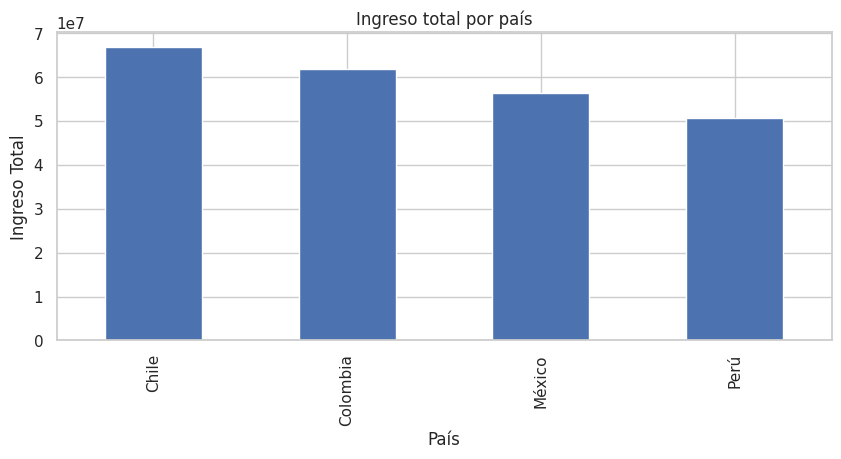

In [40]:
# Barras de ingreso por pais
ingreso_por_pais = df_limpio.groupby('pais')['ingreso'].sum().sort_values(ascending=False)

ingreso_por_pais.plot(
    kind ='bar',
    title='Ingreso total por país',
    figsize=(10,4))
plt.ylabel('Ingreso Total')
plt.xlabel('País')
plt.show()


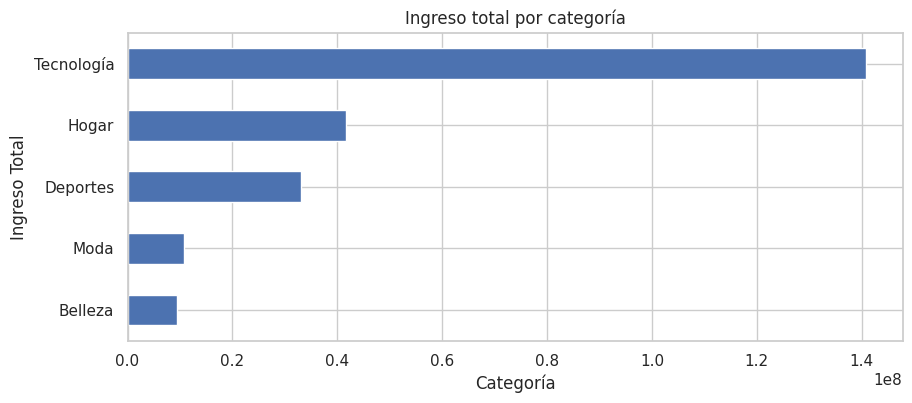

In [41]:
# Barras horizontales de ingreso por categoría
ingreso_categoria = df_limpio.groupby('categoria')['ingreso'].sum().sort_values(ascending=True)

ingreso_categoria.plot(
    kind ='barh',
    title='Ingreso total por categoría',
    figsize=(10,4))
plt.ylabel('Ingreso Total')
plt.xlabel('Categoría')
plt.show()

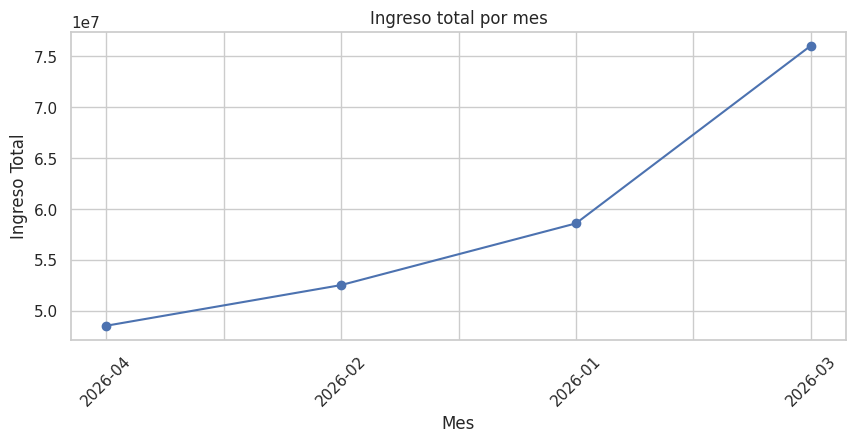

In [42]:
# Línea de ingreso por mes.

df_limpio['mes'] = df_limpio['fecha'].dt.to_period('M').astype(str)

ingreso_mes = df_limpio.groupby('mes')['ingreso'].sum().sort_values(ascending=True)

ingreso_mes.plot(
    kind ='line',
    marker = 'o',
    title='Ingreso total por mes',
    figsize=(10,4))
plt.ylabel('Ingreso Total')
plt.xlabel('Mes')
plt.xticks(rotation=45)
plt.show()

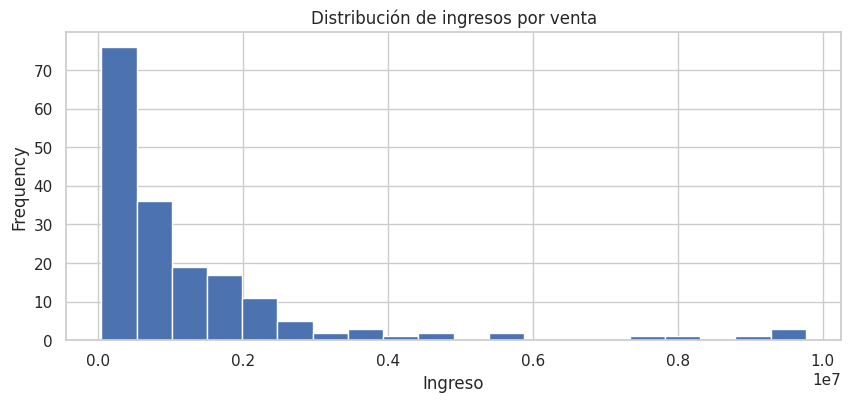

In [43]:
# Histograma de Ingresos
df_limpio['ingreso'].plot(
    kind='hist',
    bins=20,
    title='Distribución de ingresos por venta',
    figsize=(10,4)
    )
plt.xlabel('Ingreso')
plt.show();

## Ejercicio 7 · Gráficas agrupadas con Seaborn \(13 min\)

Seaborn permite comparar grupos de forma más clara usando argumentos como `hue`.

Crearemos:

1. Ingreso total por categoría separado por canal.
2. Margen porcentual por canal separado por tipo de cliente.
3. Distribución de ingresos por canal y tipo de cliente.

### Espacio de trabajo del estudiante

**Mi interpretación de la consigna:**  

**Mi procedimiento / fórmula / consulta:**  

**Resultado obtenido:**  

**Conclusión breve:**  


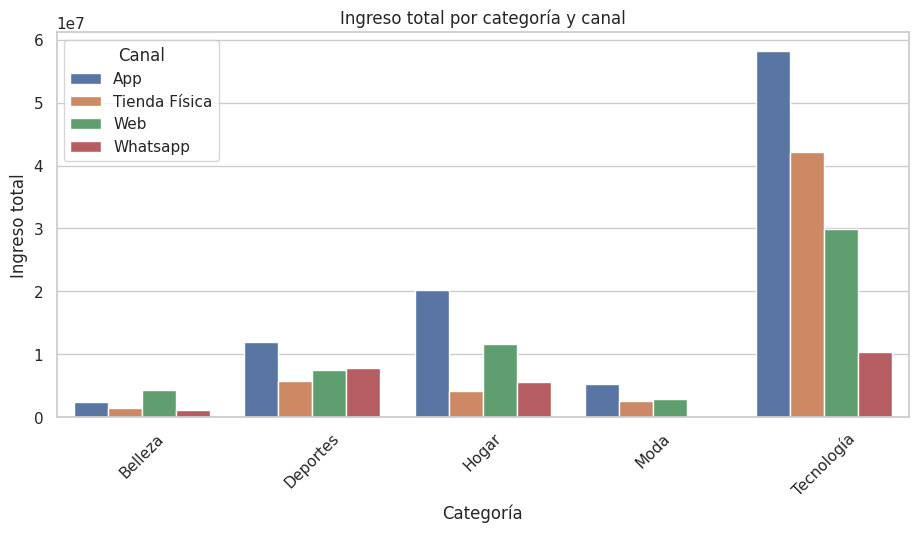

In [44]:
# Ingreso total por categoría separado por canal.
resumen_categoria_canal = df_limpio.groupby(['categoria','canal'], as_index=False).agg(ingreso_total=('ingreso', 'sum'))

plt.figure(figsize=(11,5))
sns.barplot(
    data=resumen_categoria_canal,
    x='categoria',
    y='ingreso_total',
    hue='canal'
)
plt.title('Ingreso total por categoría y canal')
plt.xlabel('Categoría')
plt.ylabel('Ingreso total')
plt.xticks(rotation=45)
plt.legend(title='Canal')
plt.show();

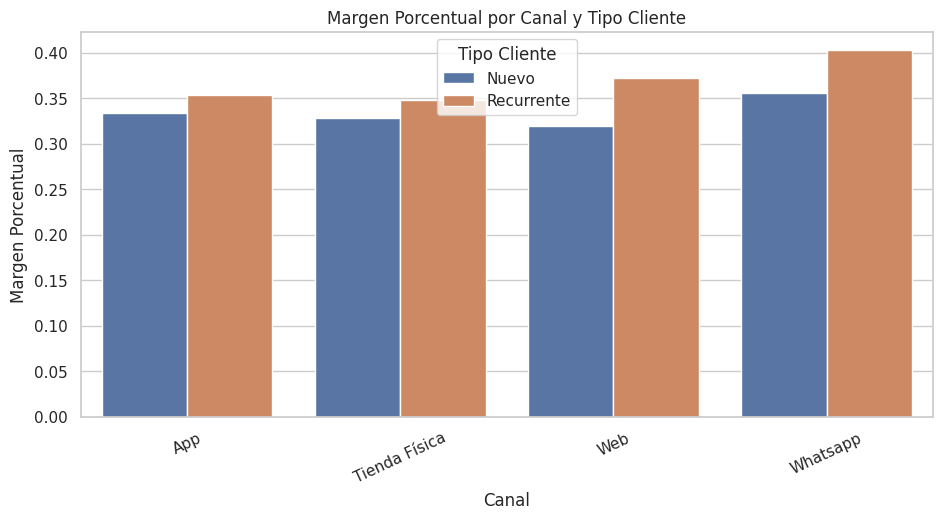

In [60]:
# Margen porcentual por canal separado por tipo de cliente.
resumen_margen = df_limpio.groupby(['canal', 'tipo_cliente'], as_index=False).agg(ingreso_total=('ingreso','sum'), margen_total=('margen', 'sum'))

resumen_margen['margen_pct'] = resumen_margen['margen_total'] / resumen_margen['ingreso_total']

# Graficar

plt.figure(figsize=(11,5))
sns.barplot(
    data=resumen_margen,
    x='canal',
    y='margen_pct',
    hue='tipo_cliente'
)
plt.title('Margen Porcentual por Canal y Tipo Cliente')
plt.xlabel('Canal')
plt.ylabel('Margen Porcentual')
plt.xticks(rotation=25)
plt.legend(title='Tipo Cliente')
plt.show()

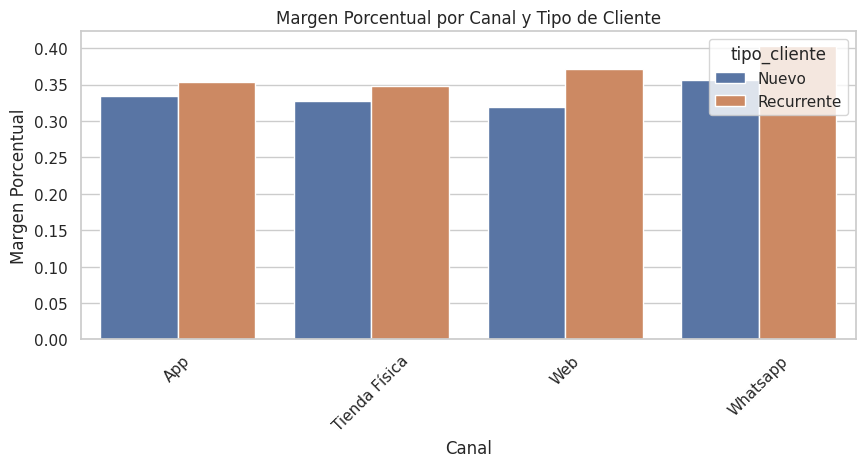

In [45]:
# Margen porcentual por canal separado por tipo de cliente.
resumen_margen = df_limpio.groupby(['canal','tipo_cliente'], as_index=False).agg(ingreso_total = ('ingreso','sum'),
                                                                margen_total = ('margen','sum')
                                                                )
resumen_margen['margen_pct'] = resumen_margen['margen_total'] / resumen_margen['ingreso_total']

plt.figure(figsize=(10,4))
sns.barplot(
    data=resumen_margen,
    x='canal',
    y='margen_pct',
    hue='tipo_cliente'
)

plt.title('Margen Porcentual por Canal y Tipo de Cliente')
plt.xlabel('Canal')
plt.ylabel('Margen Porcentual')
plt.xticks(rotation=45)
plt.legend(title='tipo_cliente')
plt.show();

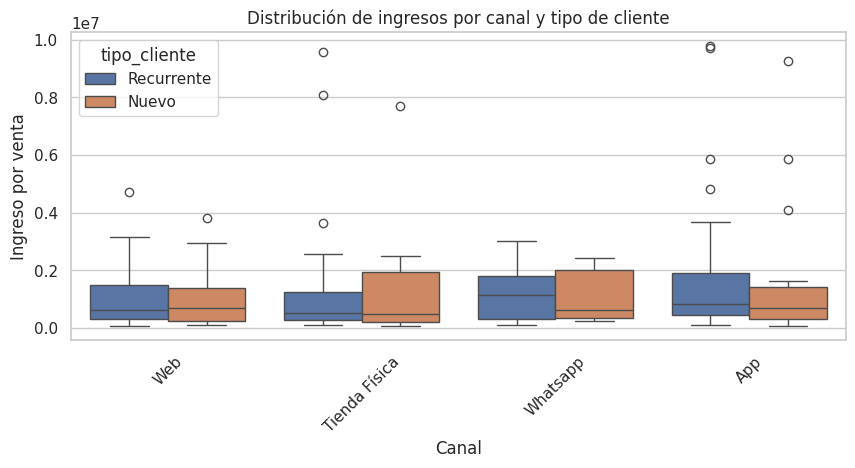

In [46]:
# Distribución de ingresos por canal y tipo de cliente.
plt.figure(figsize=(10,4))
sns.boxplot(
    data=df_limpio,
    x='canal',
    y='ingreso',
    hue='tipo_cliente'
)
plt.title('Distribución de ingresos por canal y tipo de cliente')
plt.xlabel('Canal')
plt.ylabel('Ingreso por venta')
plt.xticks(rotation=45)
plt.legend(title='tipo_cliente')
plt.show()

## Ejercicio 8 · Outliers con IQR \(8 min\)

La regla IQR permite detectar valores inusualmente altos o bajos.

No significa que esos valores estén mal. Significa que deben revisarse antes de sacar conclusiones.

### Espacio de trabajo del estudiante

**Mi interpretación de la consigna:**  

**Mi procedimiento / fórmula / consulta:**  

**Resultado obtenido:**  

**Conclusión breve:**  


In [47]:
# TODO estudiante: escribe aquí tu código.
# Función para calcular límites IQR

def calcular_limites(tabla,columna):
    q1 = tabla[columna].quantile(0.25)
    q3 = tabla[columna].quantile(0.75)
    IQR = q3 - q1
    limite_inferior = q1-1.5 * IQR
    limite_superior = q3+1.5 * IQR
    return limite_inferior, limite_superior

limite_inf, limite_sup = calcular_limites(df_limpio, 'ingreso')

print('Límite Inferior:', limite_inf)
print('Límite Superior:', limite_sup)

Límite Inferior: -1670000.0
Límite Superior: 3554200.0


In [61]:
limite_inf, limite_sup = calcular_limites(df_limpio, 'ingreso')

print('Límite Inferior:', limite_inf)
print('Límite Superior:', limite_sup)

Límite Inferior: -1670000.0
Límite Superior: 3554200.0


In [62]:
# Indentificar Ventas Atípicas por Ingreso

condicion_1 = df_limpio['ingreso'] < limit_down
condicion_2 = df_limpio['ingreso'] > limit_upper

outliers = df_limpio[(condicion_1) | (condicion_2)]
print('Cantidad de posibles outliers', len(outliers))

outliers[['venta_id', 'pais', 'canal', 'categoria', 'unidades', 'ingreso', 'margen']]

NameError: name 'limit_down' is not defined

In [63]:
# Indentificar Ventas Atípicas por Ingreso

outliers_ingreso = df_limpio[
    (df_limpio['ingreso']< limite_inf) |
    (df_limpio['ingreso']> limite_sup)
    ]
print('Cantidad de posibles outliers:', len(outliers_ingreso))
display(outliers_ingreso[['venta_id', 'pais', 'canal', 'categoria', 'unidades', 'ingreso', 'margen']].head(10))


Cantidad de posibles outliers: 14


,venta_id,pais,canal,categoria,unidades,ingreso,margen
8,V0068,Perú,App,Tecnología,2,"4,802,400.00","1,440,758.87"
12,V0037,Chile,App,Tecnología,10,"9,253,950.00","2,776,185.00"
18,V0047,Chile,App,Hogar,4,"4,084,000.00","1,178,543.29"
32,V0138,Chile,Tienda Física,Tecnología,4,"8,067,400.00","3,633,033.35"
49,V0132,Colombia,Web,Tecnología,2,"4,714,200.00","1,723,267.61"
76,V0160,Colombia,Web,Tecnología,2,"3,814,800.00","1,144,256.37"
92,V0170,Colombia,App,Deportes,15,"5,854,680.00","2,458,965.60"
99,V0104,Perú,App,Tecnología,4,"9,770,400.00","4,376,769.00"
109,V0121,Colombia,Tienda Física,Tecnología,2,"3,620,800.00","1,138,618.07"
116,V0064,México,Tienda Física,Tecnología,3,"7,703,100.00","2,494,769.23"


## Ejercicio 9 · Segmentación de ventas \(8 min\)

Segmentar ayuda a convertir números en etiquetas interpretables. Vamos a clasificar cada venta por tamaño de ingreso.

### Espacio de trabajo del estudiante

**Mi interpretación de la consigna:**  

**Mi procedimiento / fórmula / consulta:**  

**Resultado obtenido:**  

**Conclusión breve:**  


In [49]:
# Función para segmentación
def clasificar_venta(ingresos):
    if ingresos >= 4_000_000:
      return 'Alta'
    elif ingresos >= 1_500_000:
      return 'Media'
    else:
      return 'Baja'

# Aplicar función
df_limpio['segmento_venta'] = df_limpio['ingreso'].apply(clasificar_venta)

display(df_limpio[['venta_id','ingreso','segmento_venta']].head())

,venta_id,ingreso,segmento_venta
0,V0081,"344,250.00",Baja
1,V0143,"2,328,000.00",Media
2,V0077,"323,000.00",Baja
3,V0156,"133,000.00",Baja
4,V0087,"77,900.00",Baja


,count
segmento_venta,
Baja,129
Media,40
Alta,11


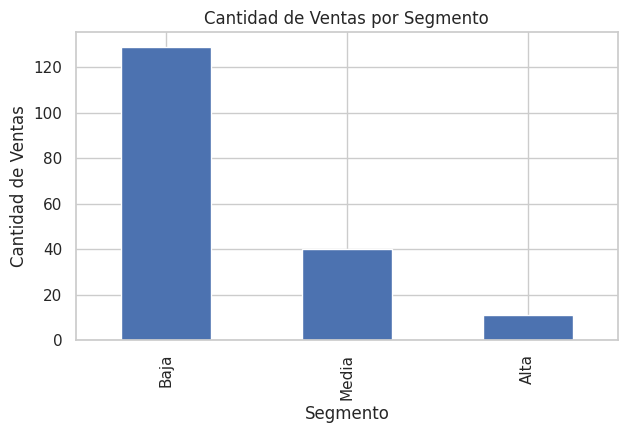

In [50]:
# Conteo por Segmento
conteo_segmento = df_limpio['segmento_venta'].value_counts()

display(conteo_segmento)

conteo_segmento.plot(
    kind='bar',
    title='Cantidad de Ventas por Segmento',
    figsize=(7,4)
    )

plt.xlabel('Segmento')
plt.ylabel('Cantidad de Ventas')
plt.show();


## Ejercicio 10 · Reto final del proyecto \(8 min\)

Construye una tabla final con una recomendación de negocio.

Tarea:

1. Agrupa por `pais`, `canal` y `categoria`.
2. Calcula ingreso total, margen total, cantidad de ventas y margen porcentual.
3. Ordena de mayor a menor ingreso.
4. Selecciona los 10 primeros registros.
5. Escribe una conclusión usando esta estructura:

> En `[país/canal/categoría]` se observa `[hallazgo]`, porque `[evidencia]`. Esto sugiere `[acción o pregunta de negocio]`.

### Espacio de trabajo del estudiante

**Mi interpretación de la consigna:**  

**Mi procedimiento / fórmula / consulta:**  

**Resultado obtenido:**  

**Conclusión breve:**  


In [64]:
# Tabla final para recomendación
ranking_final = (
    df_limpio
    .groupby(['pais','canal','categoria'], as_index=False)
    .agg(
        ingreso_total = ('ingreso', 'sum'),
        margen_total  = ('margen' , 'sum'),
        ventas = ('venta_id', 'count')
    )
)

ranking_final['margen_pct'] = ranking_final['margen_total'] / ranking_final['ingreso_total']
ranking_final = ranking_final.sort_values('ingreso_total', ascending=False)

ranking_final.head(10)

,pais,canal,categoria,ingreso_total,margen_total,ventas,margen_pct
55,Perú,App,Tecnología,"26,959,450.00","10,158,490.79",7,0.38
7,Chile,Tienda Física,Tecnología,"22,767,300.00","8,119,124.47",5,0.36
4,Chile,App,Tecnología,"20,588,850.00","6,497,859.86",6,0.32
27,Colombia,Web,Tecnología,"15,838,150.00","5,008,654.70",6,0.32
16,Colombia,App,Hogar,"10,544,700.00","3,443,056.33",9,0.33
41,México,Tienda Física,Tecnología,"9,590,400.00","3,185,700.50",3,0.33
46,México,Web,Tecnología,"8,444,000.00","3,463,633.51",5,0.41
36,México,App,Tecnología,"8,215,350.00","2,558,976.66",4,0.31
22,Colombia,Tienda Física,Tecnología,"6,253,200.00","1,856,716.73",3,0.30
44,México,Web,Hogar,"6,221,400.00","2,149,599.07",4,0.35


In [51]:
# Tabla final para recomendación

ranking_final =(
    df_limpio
    .groupby(['pais','canal','categoria'],as_index=False)
    .agg(
        ingreso_total=('ingreso','sum'),
        margen_total=('margen','sum'),
        ventas=('venta_id','count')
    )
)

ranking_final['margen_pct'] = ranking_final['margen_total'] / ranking_final['ingreso_total']
ranking_final = ranking_final.sort_values('ingreso_total', ascending=False)

ranking_final.head(10)

,pais,canal,categoria,ingreso_total,margen_total,ventas,margen_pct
55,Perú,App,Tecnología,"26,959,450.00","10,158,490.79",7,0.38
7,Chile,Tienda Física,Tecnología,"22,767,300.00","8,119,124.47",5,0.36
4,Chile,App,Tecnología,"20,588,850.00","6,497,859.86",6,0.32
27,Colombia,Web,Tecnología,"15,838,150.00","5,008,654.70",6,0.32
16,Colombia,App,Hogar,"10,544,700.00","3,443,056.33",9,0.33
41,México,Tienda Física,Tecnología,"9,590,400.00","3,185,700.50",3,0.33
46,México,Web,Tecnología,"8,444,000.00","3,463,633.51",5,0.41
36,México,App,Tecnología,"8,215,350.00","2,558,976.66",4,0.31
22,Colombia,Tienda Física,Tecnología,"6,253,200.00","1,856,716.73",3,0.30
44,México,Web,Hogar,"6,221,400.00","2,149,599.07",4,0.35


In [52]:
# Exportar resultados principales

ranking_final.to_csv('ranking_final_ventas.csv', index=False)
df_limpio.to_csv('ventas_multicanal_limpio.csv', index=False)

print('Archivos exportados:')
print('- ranking_final_ventas.csv')
print('- ventas_multicanal_limpio.csv')

Archivos exportados:
- ranking_final_ventas.csv
- ventas_multicanal_limpio.csv


In [53]:
df.to_csv('ventas_multicanal_original.csv', index=False)

## Estructura sugerida para GitHub

```text
sprint07-proyecto-ventas-python/
├── data/
│   ├── sprint07_proyecto_ventas_multicanal_latam.csv
│   └── sprint07_ventas_multicanal_limpio.csv
├── notebooks/
│   └── Sprint07_Sesion_Unica_Proyecto_Practico_120min_Python.ipynb
├── outputs/
│   └── sprint07_ranking_final_ventas.csv
└── README.md
```

### README mínimo

```markdown
# Sprint 7 · Proyecto de ventas multicanal LATAM

## Objetivo
Analizar ventas, margen, canales, categorías, outliers y segmentos usando Python.

## Herramientas
Google Colab, Python, Pandas, Matplotlib y Seaborn.

## Pasos principales
1. Cargar datos.
2. Explorar estructura y calidad.
3. Limpiar valores nulos y textos.
4. Calcular KPIs.
5. Visualizar con Pandas y Seaborn.
6. Detectar outliers.
7. Segmentar ventas.
8. Comunicar hallazgos.
```

## Preguntas de validación de conocimiento

Responde individualmente y luego valida en plenaria:

1. ¿Por qué creamos `df_limpio = df.copy()` antes de limpiar?
2. ¿Qué diferencia hay entre `df.head()` y `df.info()`?
3. ¿Para qué sirve `groupby()` en un análisis de negocio?
4. ¿Qué ventaja tiene usar un ciclo `for` al revisar varias columnas?
5. ¿Qué problema puede ocurrir si eliminamos outliers sin analizarlos?
6. ¿Qué aporta Seaborn frente a una gráfica básica con `.plot()`?
7. ¿Qué significa usar `hue` en una gráfica de Seaborn?
8. ¿Qué archivo exportamos al final y para qué serviría?

### Mis respuestas

> Escribe aquí tus respuestas antes de la discusión en clase.

1.
2.
3.

### Mis respuestas de validación

1.  
2.  
3.  

**Tema que necesito repasar:**  


## Takeaways

- Un proyecto de análisis necesita orden: cargar, explorar, limpiar, analizar, visualizar y comunicar.
- `df.copy()` ayuda a trabajar de forma segura sin perder el dataset original.
- Los valores nulos no siempre se eliminan; también pueden imputarse o marcarse.
- `for`, `while` y funciones pequeñas ayudan a reducir código repetido.
- `groupby()` conecta Python con preguntas de negocio.
- `.plot()` es suficiente para visualizaciones rápidas y claras.
- Seaborn permite comparar grupos con mayor facilidad usando `hue`.
- Los outliers deben investigarse antes de tomar decisiones sobre ellos.
- Una buena conclusión combina hallazgo, evidencia e implicación.

### Mis respuestas de validación

1.  
2.  
3.  

**Tema que necesito repasar:**  


## Cierre

Pregunta final para discusión:

> Si tuvieras que presentar solo un hallazgo de este proyecto al negocio, ¿cuál elegirías y qué gráfica usarías para defenderlo?

Cierre sugerido:

1. Compartir una tabla o gráfica final.
2. Explicar un hallazgo con evidencia.
3. Proponer una acción o siguiente análisis.
4. Guardar el notebook y los archivos generados.

## Canales de ayuda

Para resolver dudas después de la sesión, usa los canales definidos por el programa:

- Canal de preguntas de la cohorte.
- Espacios de tutoría o mentoría.
- Revisión entre pares.
- Documentación oficial de Pandas, Matplotlib y Seaborn.
- Comentarios dentro del notebook para explicar decisiones de limpieza o análisis.

Cuando pidas ayuda, intenta incluir:

1. Qué querías hacer.
2. Qué código ejecutaste.
3. Qué error o resultado obtuviste.
4. Qué intentaste revisar antes de preguntar.

## Información complementaria

Temas sugeridos para practicar después:

- Crear una nueva columna `rentabilidad` con reglas de negocio.
- Comparar ventas con y sin devolución.
- Crear una gráfica agrupada por `pais` y `tipo_cliente`.
- Cambiar los límites de segmentación y comparar resultados.
- Crear una función que reciba una columna y genere automáticamente una gráfica.
- Publicar el notebook y el dataset en GitHub con un README claro.